# Modeling â€” Retail Demand Forecasting

This notebook trains and evaluates forecasting models using the cleaned Walmart dataset. It includes Prophet for a single product-series forecast and XGBoost for a broader time-series regression model.

In [1]:
# Cell 1 â€” Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
print("All imports successful")

All imports successful


In [2]:
# Cell 2 â€” Load clean data
df = pd.read_csv('../data/processed/walmart_clean.csv', parse_dates=['Date'])

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min()} â†’ {df['Date'].max()}")
print(f"Stores     : {df['Store'].nunique()}")
print(f"Departments: {df['Dept'].nunique()}")
df.head()

Shape      : (420285, 16)
Date range : 2010-02-05 00:00:00 â†’ 2012-10-26 00:00:00
Stores     : 45
Departments: 81


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


In [3]:
# Cell 3 â€” Prophet: train on Store 1, Dept 1
store_id = 1
dept_id  = 1

prophet_df = (
    df[(df['Store'] == store_id) & (df['Dept'] == dept_id)]
    [['Date','Weekly_Sales','IsHoliday']]
    .rename(columns={'Date':'ds','Weekly_Sales':'y'})
    .sort_values('ds')
    .reset_index(drop=True)
)

print(f"Prophet training rows: {len(prophet_df)}")
prophet_df.head()

Prophet training rows: 143


,ds,y,IsHoliday
0,2010-02-05,24924.50,False
1,2010-02-12,46039.49,True
2,2010-02-19,41595.55,False
3,2010-02-26,19403.54,False
4,2010-03-05,21827.90,False


In [4]:
# Cell 4 â€” Define holidays for Prophet
holidays = pd.DataFrame({
    'holiday': [
        'SuperBowl','SuperBowl','SuperBowl',
        'LaborDay','LaborDay','LaborDay',
        'Thanksgiving','Thanksgiving','Thanksgiving',
        'Christmas','Christmas','Christmas'
    ],
    'ds': pd.to_datetime([
        '2010-02-12','2011-02-11','2012-02-10',
        '2010-09-10','2011-09-09','2012-09-07',
        '2010-11-26','2011-11-25','2012-11-23',
        '2010-12-31','2011-12-30','2012-12-28'
    ]),
    'lower_window': 0,
    'upper_window': 1
})

print("Holidays defined:")
print(holidays)

Holidays defined:
         holiday         ds  lower_window  upper_window
0      SuperBowl 2010-02-12             0             1
1      SuperBowl 2011-02-11             0             1
2      SuperBowl 2012-02-10             0             1
3       LaborDay 2010-09-10             0             1
4       LaborDay 2011-09-09             0             1
5       LaborDay 2012-09-07             0             1
6   Thanksgiving 2010-11-26             0             1
7   Thanksgiving 2011-11-25             0             1
8   Thanksgiving 2012-11-23             0             1
9      Christmas 2010-12-31             0             1
10     Christmas 2011-12-30             0             1
11     Christmas 2012-12-28             0             1


In [5]:
# Cell 5 â€” Fit Prophet model
prophet_model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

prophet_model.fit(prophet_df)
print("Prophet model fitted successfully")

11:49:22 - cmdstanpy - INFO - Chain [1] start processing


11:49:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted successfully


Prophet â€” Store 1, Dept 1
MAE  : $3,359
RMSE : $5,624
MAPE : 13.6%


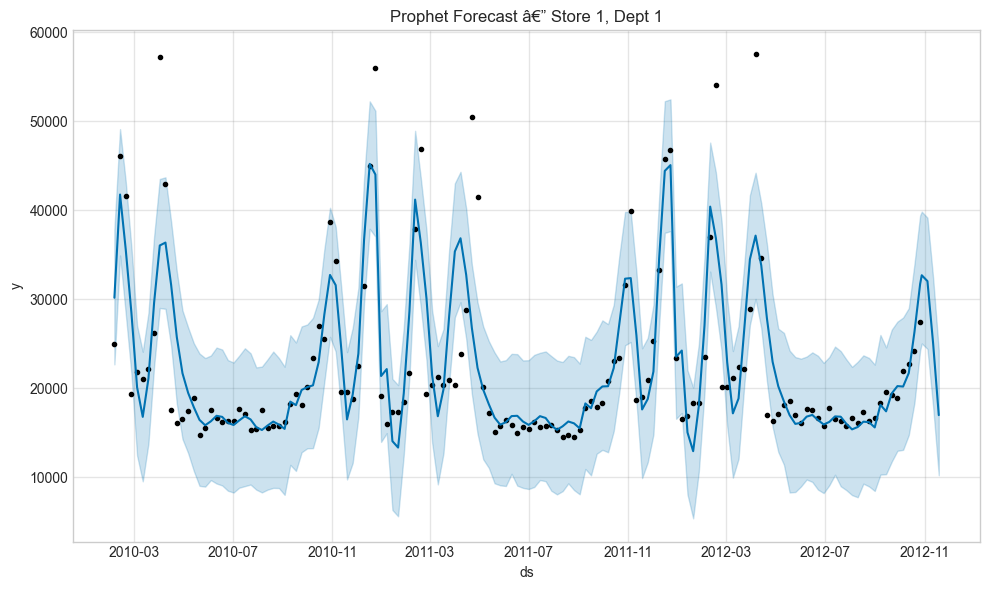

In [6]:
# Cell 6 â€” Prophet forecast + evaluation
future = prophet_model.make_future_dataframe(periods=4, freq='W')
forecast = prophet_model.predict(future)

eval_df = prophet_df.merge(
    forecast[['ds','yhat','yhat_lower','yhat_upper']],
    on='ds', how='inner'
)

mae  = mean_absolute_error(eval_df['y'], eval_df['yhat'])
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))
mape = (np.abs((eval_df['y'] - eval_df['yhat']) / eval_df['y'].replace(0, np.nan)).mean()) * 100

print(f"Prophet â€” Store {store_id}, Dept {dept_id}")
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.1f}%")

fig = prophet_model.plot(forecast)
plt.title(f'Prophet Forecast â€” Store {store_id}, Dept {dept_id}')
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 â€” Feature engineering for XGBoost
def build_features(df):
    df = df.copy()
    df = df.sort_values(['Store','Dept','Date'])

    df['Week']        = df['Date'].dt.isocalendar().week.astype(int)
    df['Month']       = df['Date'].dt.month
    df['Quarter']     = df['Date'].dt.quarter
    df['Year']        = df['Date'].dt.year
    df['IsHoliday']   = df['IsHoliday'].astype(int)

    grp = df.groupby(['Store','Dept'])['Weekly_Sales']
    df['lag_1']       = grp.shift(1)
    df['lag_4']       = grp.shift(4)
    df['lag_8']       = grp.shift(8)
    df['lag_52']      = grp.shift(52)

    df['rolling_mean_4']  = grp.shift(1).transform(lambda x: x.rolling(4,  min_periods=1).mean())
    df['rolling_mean_12'] = grp.shift(1).transform(lambda x: x.rolling(12, min_periods=1).mean())
    df['rolling_std_4']   = grp.shift(1).transform(lambda x: x.rolling(4,  min_periods=1).std().fillna(0))

    df['MarkDown_Total'] = (
        df['MarkDown1'] + df['MarkDown2'] +
        df['MarkDown3'] + df['MarkDown4'] + df['MarkDown5']
    )

    le = LabelEncoder()
    df['Type_enc'] = le.fit_transform(df['Type'])

    return df

df_feat = build_features(df)
df_feat = df_feat.dropna(subset=['lag_1','lag_4']).reset_index(drop=True)

print(f"Feature dataset shape: {df_feat.shape}")
df_feat.head()

Feature dataset shape: (407188, 29)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Week,Month,Quarter,Year,lag_1,lag_4,lag_8,lag_52,rolling_mean_4,rolling_mean_12,rolling_std_4,MarkDown_Total,Type_enc
0,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,1,2010,19403.54,24924.50,NaN,NaN,32990.7700,32990.770000,12832.106391,0.0,0
1,1,1,2010-03-12,21043.39,0,57.79,2.667,0.0,0.0,0.0,0.0,0.0,211.380643,8.106,A,151315,10,3,1,2010,21827.90,46039.49,NaN,NaN,32216.6200,30758.196000,13554.047185,0.0,0
2,1,1,2010-03-19,22136.64,0,54.58,2.720,0.0,0.0,0.0,0.0,0.0,211.215635,8.106,A,151315,11,3,1,2010,21043.39,41595.55,NaN,NaN,25967.5950,29139.061667,10467.484020,0.0,0
3,1,1,2010-03-26,26229.21,0,51.45,2.732,0.0,0.0,0.0,0.0,0.0,211.018042,8.106,A,151315,12,3,1,2010,22136.64,19403.54,NaN,NaN,21102.8675,28138.715714,1222.784968,0.0,0
4,1,1,2010-04-02,57258.43,0,62.27,2.719,0.0,0.0,0.0,0.0,0.0,210.820450,7.808,A,151315,13,4,2,2010,26229.21,21827.90,24924.5,NaN,22809.2850,27900.027500,2325.929203,0.0,0


In [8]:
# Cell 8 â€” XGBoost train/test split
FEATURES = [
    'Store','Dept','Week','Month','Quarter','Year',
    'IsHoliday','Type_enc','Size',
    'Temperature','Fuel_Price','CPI','Unemployment',
    'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','MarkDown_Total',
    'lag_1','lag_4','lag_8','lag_52',
    'rolling_mean_4','rolling_mean_12','rolling_std_4'
]

TARGET = 'Weekly_Sales'

split_date = df_feat['Date'].max() - pd.Timedelta(weeks=12)

train_df = df_feat[df_feat['Date'] <= split_date]
test_df  = df_feat[df_feat['Date'] >  split_date]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test size  : {X_test.shape[0]:,} rows")
print(f"Split date : {split_date.date()}")

Train size : 371,756 rows
Test size  : 35,432 rows
Split date : 2012-08-03


In [9]:
# Cell 9 â€” Train XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("XGBoost training complete")

[0]	validation_0-mae:14281.70262


[100]	validation_0-mae:1240.54950


[187]	validation_0-mae:1218.01334


XGBoost training complete


XGBoost â€” All stores, all departments
MAE  : $1,216
RMSE : $2,558
MAPE : 954.5%


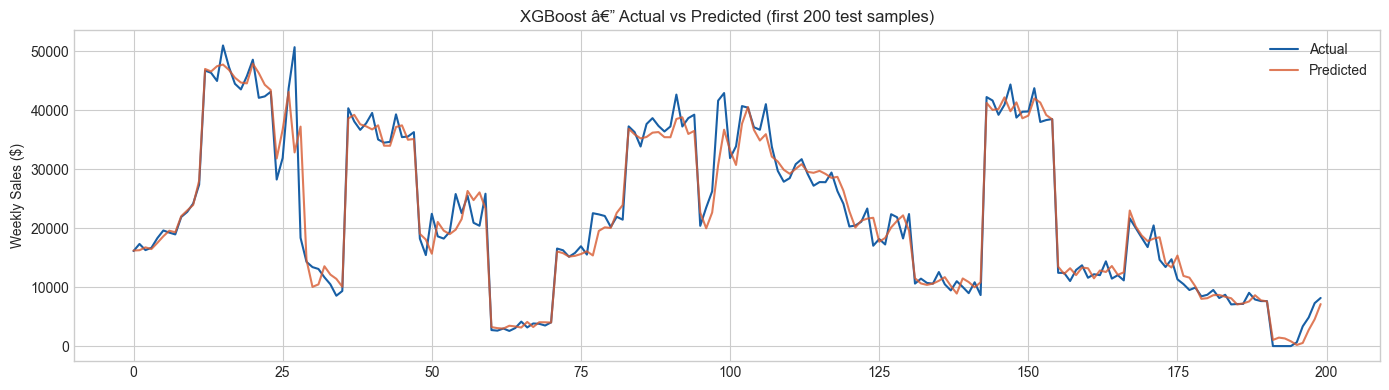

In [10]:
# Cell 10 â€” XGBoost evaluation
y_pred = xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = (np.abs((y_test - y_pred) / y_test.replace(0, np.nan)).mean()) * 100

print("XGBoost â€” All stores, all departments")
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.1f}%")

plt.figure(figsize=(14,4))
plt.plot(y_test.values[:200], label='Actual',    color='#185FA5', linewidth=1.5)
plt.plot(y_pred[:200],        label='Predicted', color='#D85A30', linewidth=1.5, alpha=0.8)
plt.title('XGBoost â€” Actual vs Predicted (first 200 test samples)')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

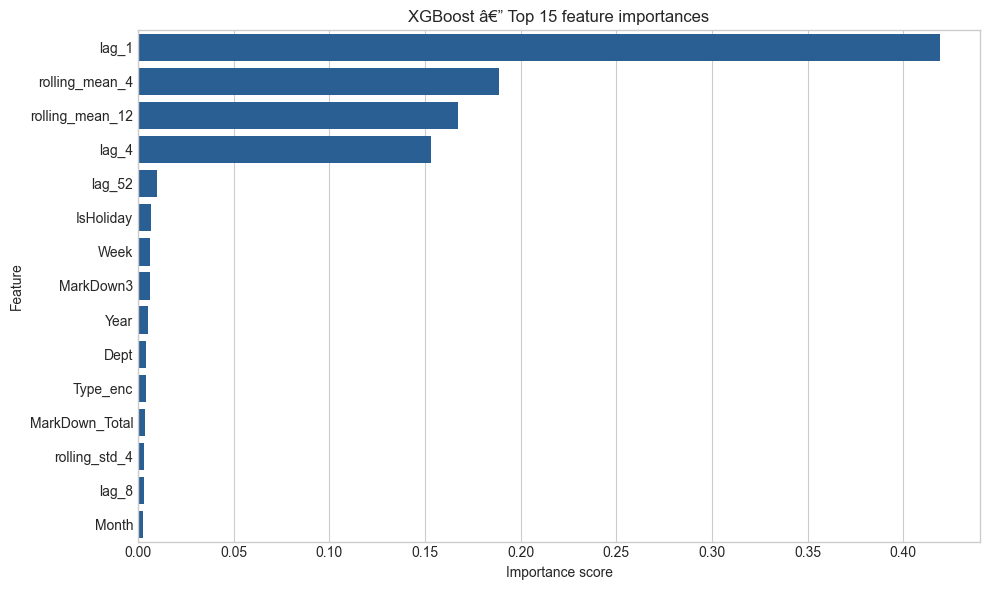

Top 5 features:
        Feature  Importance
          lag_1    0.419201
 rolling_mean_4    0.188811
rolling_mean_12    0.167391
          lag_4    0.153191
         lag_52    0.010110


In [11]:
# Cell 11 â€” Feature importance plot
importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='#185FA5')
plt.title('XGBoost â€” Top 15 feature importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importance_df.head(5).to_string(index=False))

In [12]:
# Cell 12 â€” Ensemble blend + save models
prophet_test = (
    test_df[(test_df['Store'] == 1) & (test_df['Dept'] == 1)]
    [['Date','Weekly_Sales']]
    .rename(columns={'Date':'ds','Weekly_Sales':'y_actual'})
)

prophet_pred_test = forecast[forecast['ds'].isin(prophet_test['ds'])][['ds','yhat']]
prophet_test = prophet_test.merge(prophet_pred_test, on='ds', how='inner')

xgb_pred_s1d1 = xgb_model.predict(
    test_df[(test_df['Store'] == 1) & (test_df['Dept'] == 1)][FEATURES]
)

if len(prophet_test) > 0 and len(xgb_pred_s1d1) > 0:
    min_len = min(len(prophet_test), len(xgb_pred_s1d1))
    ensemble_pred = (
        0.4 * prophet_test['yhat'].values[:min_len] +
        0.6 * xgb_pred_s1d1[:min_len]
    )
    actual = prophet_test['y_actual'].values[:min_len]

    mae_ens  = mean_absolute_error(actual, ensemble_pred)
    rmse_ens = np.sqrt(mean_squared_error(actual, ensemble_pred))

    print("Ensemble (40% Prophet + 60% XGBoost) â€” Store 1, Dept 1")
    print(f"MAE  : ${mae_ens:,.0f}")
    print(f"RMSE : ${rmse_ens:,.0f}")

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../tableau/exports', exist_ok=True)

with open('../data/processed/prophet_model.pkl', 'wb') as f:
    pickle.dump(prophet_model, f)

xgb_model.save_model('../data/processed/xgb_model.json')

print("Models saved:")
print("  ../data/processed/prophet_model.pkl")
print("  ../data/processed/xgb_model.json")

Ensemble (40% Prophet + 60% XGBoost) â€” Store 1, Dept 1
MAE  : $730
RMSE : $919
Models saved:
  ../data/processed/prophet_model.pkl
  ../data/processed/xgb_model.json


In [13]:
# Cell 13 â€” Export predictions for Power BI
export_df = test_df[['Date','Store','Dept','Weekly_Sales','IsHoliday','Type']].copy()
export_df['XGB_Predicted'] = xgb_model.predict(test_df[FEATURES])
export_df['Residual']      = export_df['Weekly_Sales'] - export_df['XGB_Predicted']
export_df['Error_Pct']     = (
    np.abs(export_df['Residual'] / export_df['Weekly_Sales'].replace(0, np.nan)) * 100
).round(2)

export_df.to_csv('../data/processed/predictions.csv', index=False)
export_df.to_csv('../tableau/exports/predictions.csv', index=False)

print(f"Predictions exported: {export_df.shape[0]:,} rows")
print(f"Columns: {export_df.columns.tolist()}")
export_df.head()

Predictions exported: 35,432 rows
Columns: ['Date', 'Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Type', 'XGB_Predicted', 'Residual', 'Error_Pct']


,Date,Store,Dept,Weekly_Sales,IsHoliday,Type,XGB_Predicted,Residual,Error_Pct
127,2012-08-10,1,1,16119.92,0,A,16212.025391,-92.105391,0.57
128,2012-08-17,1,1,17330.70,0,A,16265.933594,1064.766406,6.14
129,2012-08-24,1,1,16286.40,0,A,16751.896484,-465.496484,2.86
130,2012-08-31,1,1,16680.24,0,A,16464.183594,216.056406,1.30
131,2012-09-07,1,1,18322.37,1,A,17520.562500,801.807500,4.38
